## Librerías

In [ ]:
# Data
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_curve,
    precision_recall_curve,
    fbeta_score,
)

# Utils
import joblib


# ── Función auxiliar: evalúa un umbral dado y retorna métricas clave ─────────
def evaluar_umbral(y_true, y_proba, threshold, nombre):
    """Imprime métricas de clasificación para un umbral específico."""
    y_pred = (y_proba >= threshold).astype(int)
    report = classification_report(y_true, y_pred, output_dict=True)
    recall_pos = report["1"]["recall"]
    f2         = fbeta_score(y_true, y_pred, beta=2)   # F2: pesa más el Recall
    print(f"{'═'*55}")
    print(f"  Umbral: {nombre}  (threshold = {threshold:.4f})")
    print(f"{'═'*55}")
    print(f"  Recall clase 1 : {recall_pos:.4f}")
    print(f"  F2 score       : {f2:.4f}")
    print(classification_report(y_true, y_pred))

## Carga de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd '/content/drive/MyDrive/Universidad'

/content/drive/MyDrive/Universidad


In [ ]:
# TODO: reemplazar cuando tengan dataset limpio
df = pd.read_csv("dataset_features.csv")

df.head()

,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,...,State_Virgin Islands,State_Virginia,State_Washington,State_West Virginia,State_Wisconsin,State_Wyoming,RaceEthnicityCategory_Hispanic,"RaceEthnicityCategory_Multiracial, Non-Hispanic","RaceEthnicityCategory_Other race only, Non-Hispanic","RaceEthnicityCategory_White only, Non-Hispanic"
0,0,3,0.0,0.0,3,0,8.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,4,0.0,0.0,3,0,6.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,3,2.0,3.0,3,1,5.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,4,0.0,0.0,3,1,7.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,1,2.0,0.0,3,1,9.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


## Separación Variable Objetivo

In [ ]:
TARGET = "HadHeartAttack"
X = df.drop(columns=["HadAngina", "HadHeartAttack"])
y = df[TARGET]

## Split

In [ ]:
# ── Splits ──────────────────────────────────────────────────────────────────
# Split primero — test queda intacto y sin tocar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Índices de cada clase
idx_negativos = np.where(y_train == 0)[0]
idx_positivos = np.where(y_train == 1)[0]

# Cuántos negativos quieres (sampling_strategy=0.3 → ratio pos/neg = 0.3)
n_negativos = int(len(idx_positivos) / 0.3)

# Muestreo aleatorio de negativos
idx_negativos_res = np.random.RandomState(42).choice(
    idx_negativos, size=n_negativos, replace=False
)

# Combinar y mezclar
idx_res = np.concatenate([idx_positivos, idx_negativos_res])
np.random.RandomState(42).shuffle(idx_res)

X_train_res = X_train.iloc[idx_res]
y_train_res = y_train.iloc[idx_res]

# Verificar
print("Train resampled:", y_train_res.value_counts())

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

Train resampled: HadHeartAttack
0    62863
1    18859
Name: count, dtype: int64


## Selección de hiperparámetros con GridSearch y validación cruzada
En esta primera experimentación se realiza una búsqueda sistemática de hiperparámetros para una red neuronal orientada a maximizar el AUC-ROC. Se construye un pipeline que encapsula el escalado y el modelo para garantizar que la normalización se aprenda únicamente con los datos de entrenamiento de cada fold, evitando data leakage. Sobre ese pipeline se define una grilla de 30 combinaciones que varía la arquitectura de la red (número de capas y neuronas), la regularización L2 (`alpha`) y la tasa de aprendizaje inicial, y se evalúa cada combinación mediante validación cruzada estratificada de 5 folds para preservar la proporción de clases en cada partición dado el desbalance del dataset. El modelo ganador se re-entrena automáticamente con todo el conjunto de entrenamiento y se evalúa por primera vez sobre el conjunto de test, que no participó en ningún momento de la búsqueda, obteniendo métricas finales de AUC, matriz de confusión y reporte de clasificación. Finalmente el mejor modelo se serializa en disco para su uso posterior.

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores hiperparámetros: {'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (128,), 'mlp__learning_rate_init': 0.0005}
Mejor AUC en CV:        0.8425
param_mlp__hidden_layer_sizes  param_mlp__alpha  param_mlp__learning_rate_init  mean_test_score  std_test_score  mean_train_score
                       (128,)            0.0010                         0.0005         0.842550        0.003026          0.862685
                        (64,)            0.0100                         0.0010         0.842504        0.003704          0.859353
                       (128,)            0.0100                         0.0010         0.842402        0.003799          0.861390
                (128, 64, 32)            0.0010                         0.0010         0.842096        0.003599          0.861870
                     (64, 32)            0.0001                         0.0010         0.841942        0.003760          0.858647
          

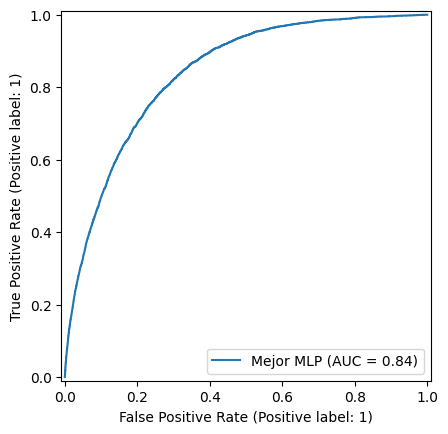

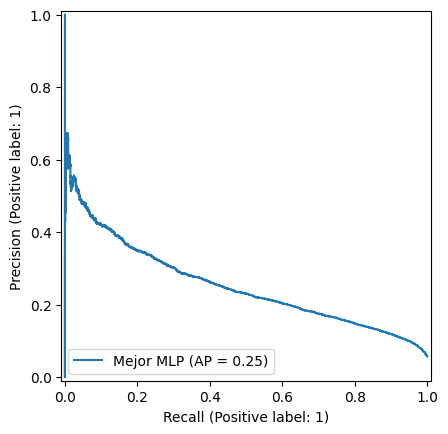

In [ ]:
# ── Pipeline (scaler + modelo juntos para no contaminar el CV) ──────────────
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        solver="adam",
        activation="relu",
        random_state=42,
        early_stopping=True,      # detiene si val_loss no mejora
        n_iter_no_change=10,
        max_iter=200,
    ))
])

# ── Grilla de hiperparámetros ───────────────────────────────────────────────
param_grid = {
    "mlp__hidden_layer_sizes": [
        (64,),
        (128,),
        (64, 32),
        (128, 64),
        (128, 64, 32),
    ],
    "mlp__alpha": [1e-4, 1e-3, 1e-2],          # L2 regularization
    "mlp__learning_rate_init": [1e-3, 5e-4],
}

# ── Validación cruzada estratificada (5 folds) ─────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",            # optimiza directamente AUC
    cv=cv,
    n_jobs=-1,                    # usa todos los núcleos disponibles
    verbose=2,
    refit=True,                   # re-entrena con TODO train usando los mejores params
    return_train_score=True,
)

search.fit(X_train_res, y_train_res)

# ── Resultados del search ───────────────────────────────────────────────────
print(f"Mejores hiperparámetros: {search.best_params_}")
print(f"Mejor AUC en CV:        {search.best_score_:.4f}")

results_df = pd.DataFrame(search.cv_results_).sort_values("mean_test_score", ascending=False)
print(results_df[[
    "param_mlp__hidden_layer_sizes",
    "param_mlp__alpha",
    "param_mlp__learning_rate_init",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
]].head(10).to_string(index=False))

# ── Evaluación final en test (datos que el modelo nunca vio) ────────────────
best_model   = search.best_estimator_
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# ── Métricas independientes del umbral ───────────────────────────────────────
auc_roc = roc_auc_score(y_test, y_proba_test)
pr_auc  = average_precision_score(y_test, y_proba_test)
print(f"ROC AUC : {auc_roc:.4f}")
print(f"PR  AUC : {pr_auc:.4f}\n")

# ── Umbral 1: Default (0.5) ───────────────────────────────────────────────────
threshold_default = 0.5

# ── Umbral 2: Youden  (maximiza Sensitivity + Specificity - 1) ───────────────
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_test)
youden_j = tpr - fpr
threshold_youden = roc_thresholds[np.argmax(youden_j)]

# ── Umbral 3: F2  (maximiza F-beta con beta=2, pesa más el Recall) ───────────
prec, rec, pr_thresholds = precision_recall_curve(y_test, y_proba_test)
f2_scores = (1 + 2**2) * (prec * rec) / (2**2 * prec + rec + 1e-9)
threshold_f2 = pr_thresholds[np.argmax(f2_scores[:-1])]

# ── Comparativa de los tres umbrales ─────────────────────────────────────────
for nombre, thr in [("Default (0.5)", threshold_default),
                    ("Youden",        threshold_youden),
                    ("F2",            threshold_f2)]:
    evaluar_umbral(y_test, y_proba_test, thr, nombre)

# ── Curvas ───────────────────────────────────────────────────────────────────
RocCurveDisplay.from_predictions(y_test, y_proba_test, name="Mejor MLP")
PrecisionRecallDisplay.from_predictions(y_test, y_proba_test, name="Mejor MLP")

## Análisis de la cantidad de capas sobre el rendimiento
En esta segunda experimentación se busca aislar el efecto de la arquitectura de la red sobre el rendimiento del modelo, con el objetivo de demostrar que el problema de bajo recall en la clase positiva no se resuelve aumentando la complejidad de la red. Para garantizar que la comparación sea justa y controlada, se fijan todos los hiperparámetros (`alpha`, `learning_rate_init`) y se varía únicamente `hidden_layer_sizes`, probando cuatro arquitecturas de complejidad creciente desde una red shallow de una sola capa oculta hasta una red profunda de cuatro capas. Al igual que en el experimento anterior, se emplea validación cruzada estratificada de 5 folds con AUC-ROC como métrica de selección, manteniendo exactamente las mismas condiciones experimentales para que los resultados sean comparables. Si el AUC y el recall de la clase positiva se mantienen similares a lo largo de todas las arquitecturas, incluyendo la más grande, queda evidenciado que el origen del problema es el desbalance de clases y no la capacidad de representación de la red.

In [ ]:
# ── Pipeline (scaler + modelo juntos para no contaminar el CV) ──────────────
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        activation="relu",
        solver="adam",
        alpha=1e-3,              # fijo — no es lo que estamos probando
        learning_rate_init=1e-3, # fijo — no es lo que estamos probando
        early_stopping=True,
        n_iter_no_change=10,
        max_iter=200,
        random_state=42,
    ))
])

# ── Grilla de Arquitecturas ───────────────────────────────────────────────
param_grid = {
    "mlp__hidden_layer_sizes": [
        (128, 64),
        (256, 128, 64),
        (512, 256, 128, 64),
        (512, 256, 128, 64, 32),
    ],
}


# ── Validación cruzada estratificada (5 folds) ─────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True,
)

search.fit(X_train_res, y_train_res)

# ── Tabla de resultados por arquitectura ───────────────────────────────────────
results_df = (
    pd.DataFrame(search.cv_results_)
    [["param_mlp__hidden_layer_sizes", "mean_test_score", "std_test_score", "mean_train_score"]]
    .rename(columns={
        "param_mlp__hidden_layer_sizes": "Arquitectura",
        "mean_test_score":               "AUC CV (val)",
        "std_test_score":                "Std",
        "mean_train_score":              "AUC CV (train)",
    })
    .sort_values("AUC CV (val)", ascending=False)
)

print("\n" + "═"*60)
print("  RESULTADOS POR ARQUITECTURA — validación cruzada 5-fold")
print("═"*60)
print(results_df.to_string(index=False))

# ── Evaluación final en test con el mejor modelo ─────────────────────────────
best_model = search.best_estimator_
y_proba    = best_model.predict_proba(X_test)[:, 1]

# ── Métricas independientes del umbral ────────────────────────────────────────
auc_roc = roc_auc_score(y_test, y_proba)
pr_auc  = average_precision_score(y_test, y_proba)
print(f"Mejor arquitectura : {search.best_params_['mlp__hidden_layer_sizes']}")
print(f"ROC AUC : {auc_roc:.4f}")
print(f"PR  AUC : {pr_auc:.4f}\n")

# ── Umbral 1: Default (0.5) ────────────────────────────────────────────────────
threshold_default = 0.5

# ── Umbral 2: Youden  (maximiza Sensitivity + Specificity - 1) ────────────────
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
youden_j = tpr - fpr
threshold_youden = roc_thresholds[np.argmax(youden_j)]

# ── Umbral 3: F2  (maximiza F-beta con beta=2, pesa más el Recall) ────────────
prec, rec, pr_thresholds = precision_recall_curve(y_test, y_proba)
f2_scores = (1 + 2**2) * (prec * rec) / (2**2 * prec + rec + 1e-9)
threshold_f2 = pr_thresholds[np.argmax(f2_scores[:-1])]

# ── Comparativa de los tres umbrales ──────────────────────────────────────────
for nombre, thr in [("Default (0.5)", threshold_default),
                    ("Youden",        threshold_youden),
                    ("F2",            threshold_f2)]:
    evaluar_umbral(y_test, y_proba, thr, nombre)

print("\nConclusión esperada: AUC y Recall cls 1 similares en todas → es desbalance")

Fitting 5 folds for each of 4 candidates, totalling 20 fits

════════════════════════════════════════════════════════════
  RESULTADOS POR ARQUITECTURA — validación cruzada 5-fold
════════════════════════════════════════════════════════════
           Arquitectura  AUC CV (val)      Std  AUC CV (train)
(512, 256, 128, 64, 32)      0.844575 0.002935        0.858354
    (512, 256, 128, 64)      0.843987 0.003080        0.864176
         (256, 128, 64)      0.842990 0.003777        0.855594
              (128, 64)      0.841248 0.002949        0.863124
Mejor arquitectura : (512, 256, 128, 64, 32)
ROC AUC : 0.8380
PR  AUC : 0.2544

═══════════════════════════════════════════════════════
  Umbral: Default (0.5)  (threshold = 0.5000)
═══════════════════════════════════════════════════════
  Recall clase 1 : 0.4229
  F2 score       : 0.3730
              precision    recall  f1-score   support

           0       0.96      0.92      0.94     77977
           1       0.25      0.42      0.32  